In [2]:
#Importar libreria para manejo de datos
import pandas as pd

#Leer archivo de test
df = pd.read_csv("g1tfm-test-dataset.csv")
#Imprimir primeras lineas para visualizar data
df.head()


,edad,ingresos_declarados,nivel_endeudamiento,score_buro,morosidad_prev,consumo_electrico,pago_serv_publicos,remesas,ingresos_bancarios,historial_empresa,pago
0,56,329.522647,0.646939,47,107,398,1,0,855.006013,0,0
1,69,595.073122,0.869617,95,113,327,1,200,765.671714,0,0
2,46,626.490843,0.775897,69,98,266,1,300,755.402371,0,0
3,32,405.164365,0.630094,26,21,50,1,200,464.725673,0,0
4,60,345.645609,0.982259,46,96,125,1,300,560.232011,0,0


In [3]:
#Remover la variable de resultado del data set para crear variable X
X = df.drop("pago", axis=1)

#Definiiendo variable y como la columna de pago
y = df["pago"]


In [6]:
#Importar libreria auxiliar para ML
from sklearn.model_selection import train_test_split

#Dividir el dataset en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [7]:
#Importar el algoritmo seleccionado
#Se selecciono este algoritmo al ser el que presenta mejores resultados en un entranamiento de autoML
from xgboost import XGBClassifier

#Configuración de hyperparametros del algortimo
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):


[03:30:49] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8,
              enable_categorical=False, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_delta_step=0, max_depth=5,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=200, n_jobs=4, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
              subsample=0.8, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [8]:
#Se importan librerias auxiliares para metricas
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

#se corren los modelos
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

#Impresion de metricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
F1: 1.0
AUC: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2187
           1       1.00      1.00      1.00       813

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):


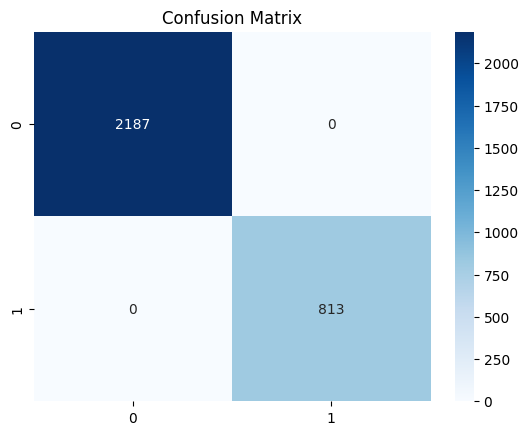

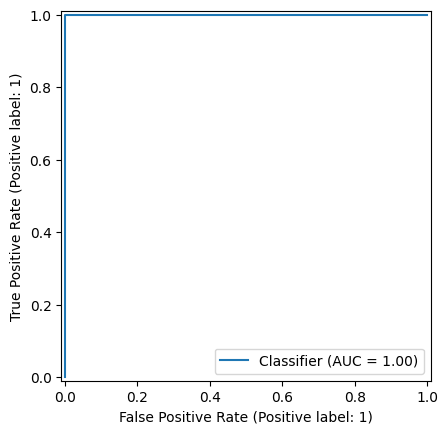

In [9]:
#Importar librerias para metricas visuales
from sklearn.metrics import confusion_matrix, RocCurveDisplay
import seaborn as sns
#Libreria de diagramación
import matplotlib.pyplot as plt

#Creación de matriz de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.show()

#Creación de Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


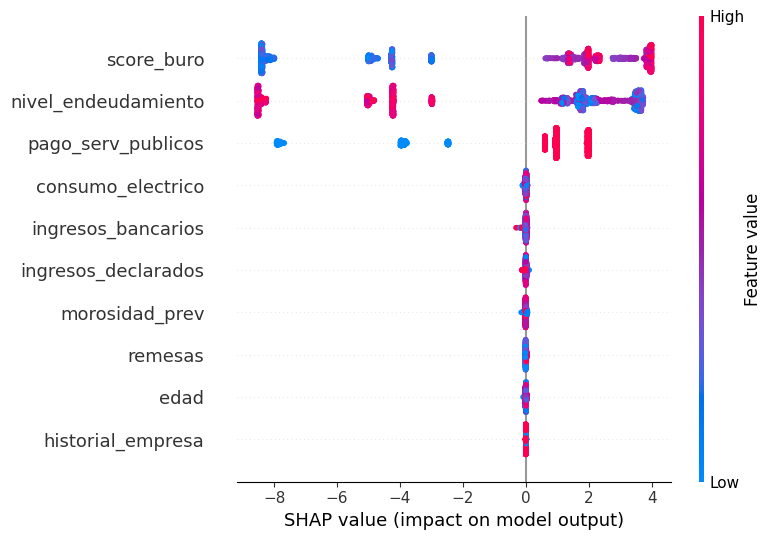

In [10]:
#Importar libreria que explica el modelo
#SHAP analiza tu modelo árbol‐basado (XGBoost) y calcula la contribución de cada variable a las predicciones.
import shap

#Explica el modelo basado en arboles
explainer = shap.TreeExplainer(model)
#Muestra ¿Cuánto contribuyó cada variable a la predicción del modelo para cada observación?
shap_values = explainer.shap_values(X_test)

#Grafica los resultados
shap.summary_plot(shap_values, X_test)
